# Plot the results of the T cell parameter estimations

Generates Figures 5a, 5b, S8, and S9.

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from scipy.stats import ttest_ind
from estimator import Estimator
from src import pyxfunc

## User-defined parameters

In [2]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_t.json"

bests_file = "bests/t_100.csv"

figure_save_path = "figures/" # Set to None to not save figures
figure_data_save_path = "figures/" # Set to None to not save figure data

## Set up

In [3]:
groups_b6 = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)", "Grp. A5 B6 (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
es = Estimator(config_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
growth_df.loc[growth_df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
growth_df.loc[growth_df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
growth_df.loc[growth_df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
growth_df.loc[growth_df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
growth_df.loc[growth_df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"

## Read in and prep data

In [4]:
bests = pd.read_csv(bests_file)
bests

,Unnamed: 0,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,log_error
0,0,Grp. A1 B6 (100% C1),424,0.166,0.000,0.000,0.000,0.04,1.9,1.7,0.03,0.01,281.85254,0,5.641384
1,1,Grp. A1 B6 (100% C1),424,0.166,0.000,0.000,0.000,0.16,0.5,0.3,0.03,0.01,358.71860,0,5.882538
2,2,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.08,1.5,1.2,0.05,0.01,453.18750,0,6.116306
3,3,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.18,0.4,0.3,0.02,0.01,468.28534,0,6.149078
4,4,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.12,1.2,1.2,0.03,0.01,495.16666,0,6.204894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3095,95,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.080,0.165,0.38,0.2,0.1,0.01,0.01,4225.64500,1,8.348927
3096,96,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.110,0.220,0.20,1.5,1.5,0.01,0.01,4226.77050,1,8.349194
3097,97,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.135,0.265,0.52,0.9,0.9,0.02,0.01,4233.92200,1,8.350884
3098,98,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.140,0.355,0.82,0.7,0.7,0.02,0.01,4234.83450,1,8.351100


# Plot best results

In [6]:
def plot_best(bests):
    plot_results = []
    
    ylim = (growth_df[growth_df["group"].isin(groups_b6)]["size"].max())+50
    xlim = growth_df[growth_df["group"].isin(groups_b6)]["day"].max()+2
        
    # Change figure size at the last part of this line if needed. First value is width, second value is height.
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12,8))
    for i in range(0,5):
        axes[0][i].set_ylim([-1, ylim])
        axes[0][i].set_xlim([6, xlim])
        group_df = growth_df[growth_df["group"] == groups_b6[i]]
        
        for mid in group_df["id"].unique():
            # Plot true data
            axes[0][i].plot(group_df[group_df["id"]==mid]["day"], (np.abs(group_df[group_df["id"]==mid]["size"])), color="black", linewidth=1)
            
            # Plot estimated data
            init = es.get_init(groups_b6[i], mid)
            end_time = group_df[group_df["id"]==mid]["day"].max()
            
            best = bests[bests["id"]==mid].sort_values("error")
                        
            sol = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, es.delay, es.cutoff_0_raw, es.cutoff_0_percent, init[2], best["g1"].tolist()[0], best["g11"].tolist()[0],
                                best["m"].tolist()[0], best["k"].tolist()[0], best["c"].tolist()[0], best["a"].tolist()[0], best["f"].tolist()[0], best["b"].tolist()[0], best["l"].tolist()[0])
            sol[0] = np.asarray(sol[0])
            sol[1] = np.asarray(sol[1])
            sol[2] = np.asarray(sol[2])
            sol[3] = np.asarray(sol[3])
            total_size = sol[0]+sol[1]

            # plot the winning subline second so it shows up
            if sol[0][-1] > sol[1][-1]: 
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", label="C11", alpha=0.6)
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", label="C1", alpha=0.8)
                color = "orange"
            else:
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", label="C1", alpha=0.8)
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", label="C11", alpha=0.6)
                color = "blue"
    
            # plot the ratios
            axes[1][i].plot(total_size, sol[0]/total_size, color="orange", label="C1")
            axes[1][i].plot(total_size, sol[1]/total_size, color="blue", label="C11")

            # plot the T cells
            axes[2][i].plot(total_size, sol[2]/(total_size+sol[2]), color="magenta", label="T")
            axes[2][i].set_ylim([0, 0.04])
            
            axes[0][i].set_title(groups_b6[i][5:7])

            plot_results += [np.concat([[groups_b6[i], mid, "C1"], sol[0]])]
            plot_results += [np.concat([[groups_b6[i], mid, "C11"], sol[1]])]
            
    axes[0][0].set_ylabel("Subclone (mm^3)")
    axes[1][0].set_ylabel("Subclone / (C1 + C11)")
    axes[2][0].set_ylabel("T cell / (C1 + C11 + T cell)")
    plt.tight_layout()
    if figure_save_path:
        plt.savefig(figure_save_path+"b6_predictions.svg")
    plt.show()

    return plot_results

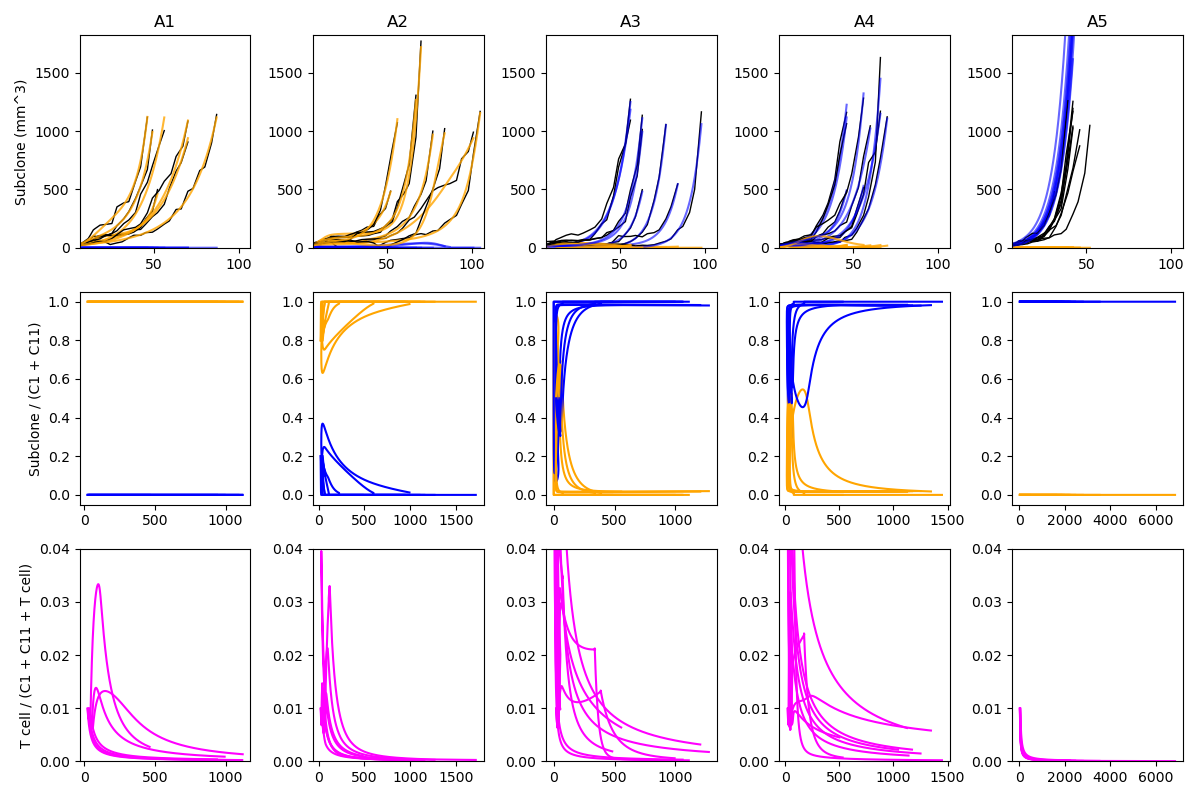

In [7]:
plot_results = plot_best(bests)

In [13]:
plot_results = pd.DataFrame(plot_results, columns=["Group", "ID", "Subclone"]+np.arange(7, 105.01, 0.01).tolist())
if figure_data_save_path:
    plot_results.to_csv(figure_data_save_path+"Figure5b.csv", index=False)

## Plot distributions of parameters across groups

In [5]:
bests_no_a5 = bests[bests["group"]!="Grp. A5 B6 (100% C11)"]
bests_no_a5 = bests_no_a5[bests_no_a5["id"]!=602]
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A1 B6 (100% C1)", "group"] = "A1"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A2 B6 (80% C1; 20% C11)", "group"] = "A2"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A3 B6 (50% C1; 50% C11)", "group"] = "A3"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A4 B6 (20% C1; 80% C11)", "group"] = "A4"
bests_no_a5 = bests_no_a5.reset_index()

if figure_data_save_path:
    bests_no_a5.to_csv(figure_data_save_path + "Figure5a.csv", index=False)

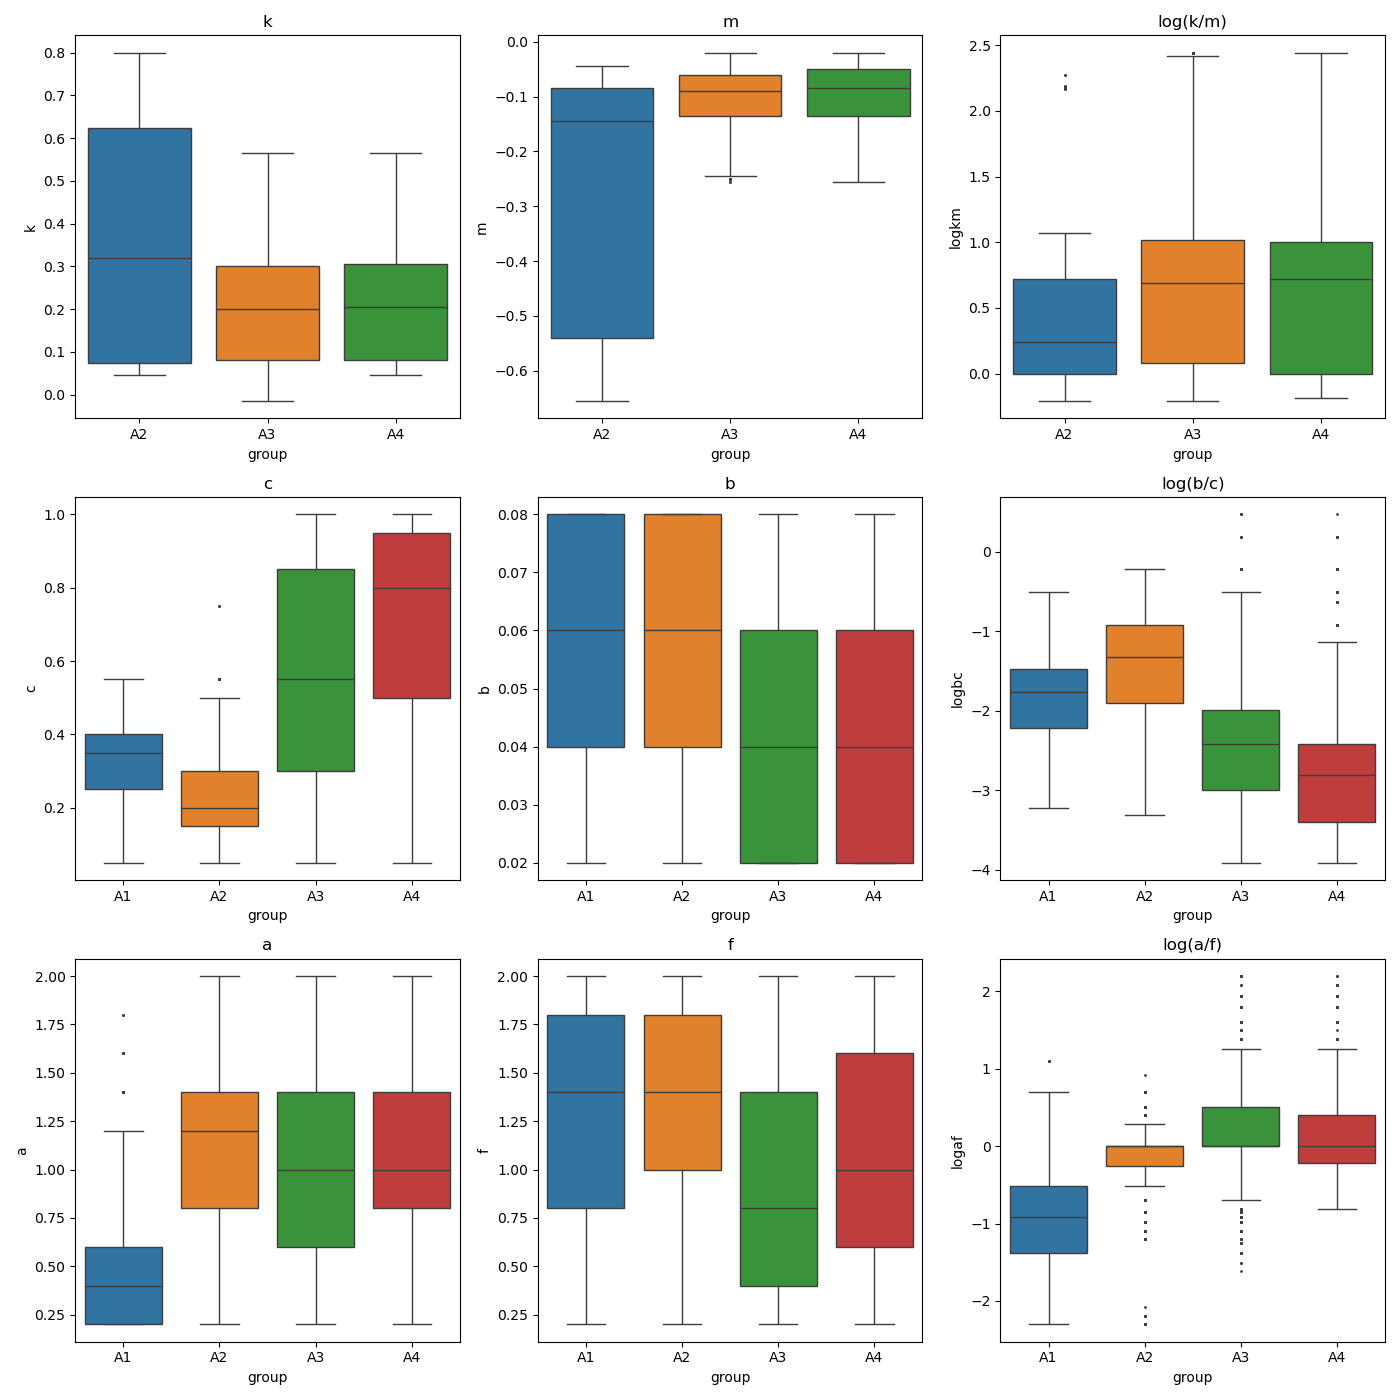

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14,14))
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="k", hue="group", fliersize=1, ax=axes[0][0])
axes[0][0].set_title("k")
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="m", hue="group", fliersize=1, ax=axes[0][1])
axes[0][1].set_title("m")
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="logkm", hue="group", fliersize=1, ax=axes[0][2])
axes[0][2].set_title("log(k/m)")
sns.boxplot(bests_no_a5, x="group", y="c", hue="group", fliersize=1, ax=axes[1][0])
axes[1][0].set_title("c")
sns.boxplot(bests_no_a5, x="group", y="b", hue="group", fliersize=1, ax=axes[1][1])
axes[1][1].set_title("b")
sns.boxplot(bests_no_a5, x="group", y="logbc", hue="group", fliersize=1, ax=axes[1][2])
axes[1][2].set_title("log(b/c)")
sns.boxplot(bests_no_a5, x="group", y="a", hue="group", fliersize=1, ax=axes[2][0])
axes[2][0].set_title("a")
sns.boxplot(bests_no_a5, x="group", y="f", hue="group", fliersize=1, ax=axes[2][1])
axes[2][1].set_title("f")
sns.boxplot(bests_no_a5, x="group", y="logaf", hue="group", fliersize=1, ax=axes[2][2])
axes[2][2].set_title("log(a/f)")
plt.tight_layout()
if figure_save_path:
    plt.savefig(figure_save_path+"b6_boxplots.svg")
plt.show()

In [53]:
plt.close("all")